In [1]:
import os
import sys
import requests
import datetime as dt
import numpy as np
from dotenv import load_dotenv
from pathlib import Path
import requests
import pandas as pd
import talib as ta
import plotly.graph_objs as go

import ipywidgets as widgets
from ipywidgets import Dropdown, Text, Button, Output
from IPython.display import display
from pathlib import Path

from Modules.utility import Utility
from Modules.show_plot import ShowPlot
from Modules.reques_api import RequestApi
from Modules.get_market_data import GetMarketData
from Modules.stock_prices_and_market_data import ClassStockPricesMarketData
from Modules.financial import Financial
from Modules.pdf_url_to_markdown import PDFUrlToMarkdown
from Modules.webpage_to_markdown import WebpageToMarkdown
from Modules.compute_fibonacci_extension import ComputeFibonacciExtension

In [2]:
API_BASE_URL = os.getenv("API_BASE_URL", "http://localhost:8000")
request_api = RequestApi(API_BASE_URL)
get_market_data = GetMarketData(Path('/workspace/data'))
utility = Utility()
stock_prices_market_data = ClassStockPricesMarketData()
financial = Financial()
# URLからPDFをダウンロードしてMarkdownに変換するクラスのインスタンスを作成
pdf_to_md = PDFUrlToMarkdown()
# WEBページをMarkdownに変換する関数
webpage_to_markdown = WebpageToMarkdown()
# 
fibonacci_extension = ComputeFibonacciExtension()

In [3]:
gold = 'GC=F'
start = '1999-01-01'
end = dt.datetime.now().strftime('%Y-%m-%d')
response = request_api.update_commodity_timeseries_data(
    code=gold,
    market=None,
    start=start,
    end=end
)
response

{'result': True}

In [4]:
gold_df = request_api.get_commodity_time_series_data(
    code=gold,
    market=None,
    start='2025-01-01',
    end=end
)
gold_df.head()

取得件数: 571


,id,commodity_id,commodity_code,commodity_market,date,open,high,low,close,adj_close,...,rci9,rci26,cross,gc,dc,macd_gc,macd_dc,rci_gc,rci_dc,rising_condition
0,5900,1,GC=F,None,2024-03-07,2158.000000,2163.000000,2147.000000,2147.000000,None,...,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,False
1,5901,1,GC=F,None,2024-03-08,2178.600098,2194.899902,2166.300049,2167.300049,None,...,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,False
2,5902,1,GC=F,None,2024-03-11,2182.500000,2184.000000,2177.199951,2181.000000,None,...,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,False
3,5903,1,GC=F,None,2024-03-12,2160.399902,2182.699951,2160.399902,2182.500000,None,...,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,False
4,5904,1,GC=F,None,2024-03-13,2175.399902,2175.399902,2162.500000,2162.500000,None,...,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,False


In [5]:
silver = 'SI=F'
start = '1999-01-01'
end = dt.datetime.now().strftime('%Y-%m-%d')
response = request_api.update_commodity_timeseries_data(
    code=silver,
    market=None,
    start=start,
    end=end
)
response

{'result': True}

In [6]:
silver_df = request_api.get_commodity_time_series_data(
    code=silver,
    market=None,
    start='2025-01-01',
    end=end
)
silver_df.head()

取得件数: 571


,id,commodity_id,commodity_code,commodity_market,date,open,high,low,close,adj_close,...,rci9,rci26,cross,gc,dc,macd_gc,macd_dc,rci_gc,rci_dc,rising_condition
0,12338,2,SI=F,None,2024-03-07,24.370001,24.514999,24.139999,24.165001,None,...,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,False
1,12339,2,SI=F,None,2024-03-08,24.339001,24.504999,24.299999,24.504999,None,...,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,False
2,12340,2,SI=F,None,2024-03-11,24.511999,24.511999,24.370001,24.385000,None,...,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,False
3,12341,2,SI=F,None,2024-03-12,24.194000,24.504999,24.194000,24.465000,None,...,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,False
4,12342,2,SI=F,None,2024-03-13,24.959000,24.959000,24.215000,24.215000,None,...,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,False


In [7]:
code = 'LG'
market = 'V'
start = '1999-01-01'
end = dt.datetime.now().strftime('%Y-%m-%d')

response = request_api.update_stock_timeseries_data(
    code=code,
    market=market,
    start=start,
    end=end
)
response

{'result': True}

In [8]:
lg_timeseries_df = request_api.get_stock_time_series_data(
    code=code,
    market=market,
    start=start,
    end=end
)
lg_timeseries_df

取得件数: 1046


,id,stock_code,stock_market,date,open,high,low,close,volume,ma5,...,upper1,lower1,cross,gc,dc,macd_gc,macd_dc,rci_gc,rci_dc,rising_condition
0,1210266,LG,V,2022-04-13,0.380,0.450,0.350,0.350,615000,NaN,...,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,False
1,1210267,LG,V,2022-04-14,0.380,0.400,0.380,0.390,255700,NaN,...,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,False
2,1210268,LG,V,2022-04-18,0.400,0.400,0.400,0.400,483847,NaN,...,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,False
3,1210269,LG,V,2022-04-19,0.400,0.400,0.400,0.400,71500,NaN,...,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,False
4,1210270,LG,V,2022-04-20,0.400,0.400,0.400,0.400,0,0.388,...,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1041,1248262,LG,V,2026-06-08,0.345,0.375,0.345,0.375,807049,0.391,...,0.399638,0.372362,True,NaN,NaN,NaN,NaN,NaN,NaN,False
1042,1248263,LG,V,2026-06-09,0.340,0.375,0.330,0.355,2206769,0.382,...,0.399975,0.371225,False,NaN,0.3856,NaN,NaN,NaN,NaN,False
1043,1248264,LG,V,2026-06-10,0.325,0.350,0.325,0.330,784863,0.368,...,0.401797,0.367003,False,NaN,NaN,NaN,NaN,NaN,NaN,False
1044,1248265,LG,V,2026-06-11,0.360,0.360,0.320,0.325,1199888,0.353,...,0.403444,0.362156,False,NaN,NaN,NaN,NaN,NaN,NaN,False


In [9]:
def stock_prices_and_gold_prices(
        code: str,
        name: str,
        start: str,
        end: str,
        df_stock: pd.DataFrame | None = None,
        df_sp: pd.DataFrame | None = None,
        df_gold: pd.DataFrame | None = None,
        df_silver: pd.DataFrame | None = None
    ):
    # /api/v1/time_series_data/stock/
    if df_stock is None:
        response = request_api.get_stock_time_series_data(
            code=code,
            market=None,
            start=start,
            end=end
        )
        df_stock = pd.DataFrame(response)

    # S&P500を統合
    if df_sp is not None:
        df_sp_tmp = df_sp.copy() if df_sp is not None else pd.DataFrame()
        if "date" not in df_sp_tmp.columns:
            df_sp_tmp = df_sp_tmp.reset_index()

        df_sp_tmp["date"] = pd.to_datetime(df_sp_tmp["date"])
        df_sp_tmp = df_sp_tmp.set_index("date")
        df_sp_tmp = df_sp_tmp.loc[start:end]

    # 金価格を統合
    if df_gold is not None:
        df_gold_tmp = df_gold.copy() if df_gold is not None else pd.DataFrame()
        if "date" not in df_gold_tmp.columns:
            df_gold_tmp = df_gold_tmp.reset_index()
        df_gold_tmp["date"] = pd.to_datetime(df_gold_tmp["date"])
        df_gold_tmp = df_gold_tmp.set_index("date")
        df_gold_tmp = df_gold_tmp.loc[start:end]

    # 銀価格を統合
    if df_silver is not None:
        df_silver_tmp = df_silver.copy() if df_silver is not None else pd.DataFrame()
        if "date" not in df_silver_tmp.columns:
            df_silver_tmp = df_silver_tmp.reset_index()
        df_silver_tmp["date"] = pd.to_datetime(df_silver_tmp["date"])
        df_silver_tmp = df_silver_tmp.set_index("date")
        df_silver_tmp = df_silver_tmp.loc[start:end]

    # 金価格
    df = df_stock.copy()
    df["date"] = pd.to_datetime(df["date"])
    df = df.set_index("date")
    df = df.loc[start:end]


    # インデックスを揃えて結合
    if df_sp is not None:
        df["MA5_SP"] = df_sp_tmp["ma5"].reindex(df.index)
        df["MA25_SP"] = df_sp_tmp["ma25"].reindex(df.index)
    if df_gold is not None:
        df["MA5_GOLD"] = df_gold_tmp["ma5"].reindex(df.index)
        df["MA25_GOLD"] = df_gold_tmp["ma25"].reindex(df.index)
    if df_silver is not None:
        df["MA5_SILVER"] = df_silver_tmp["ma5"].reindex(df.index)
        df["MA25_SILVER"] = df_silver_tmp["ma25"].reindex(df.index)

    show_plot = ShowPlot()
    fig = show_plot.create_basic_chart(
        df=df.reset_index(),
        code=code,
        name=name,
        start=start,
        end=end
    )
    # ★ 2つのY軸を定義（左：HYMC、右：SP500 & GOLD）
    fig.update_layout(
        yaxis=dict(
            title=f"{name} Price",
            side="left"
        ),
        yaxis2=dict(
            title="SP500 / GOLD",
            overlaying="y",
            side="right"
        )
    )

    # --- SP500（右軸） ---
    if df_sp is not None:
        fig.add_trace(
            go.Scatter(
                x=df.index,
                y=df["MA5_SP"],
                name="SP_MA5",
                line={"color": "blue", "width": 1.2},
                yaxis="y2"   # ★ 右軸
            )
        )
        fig.add_trace(
            go.Scatter(
                x=df.index,
                y=df["MA25_SP"],
                name="SP_MA25",
                line={"color": "gray", "width": 1.2},
                yaxis="y2"   # ★ 右軸
            )
        )

    # --- GOLD（右軸） ---
    if df_gold is not None:
        fig.add_trace(
            go.Scatter(
                x=df.index,
                y=df["MA5_GOLD"],
                name="GOLD_MA5",
                line={"color": "orange", "width": 1.2},
                yaxis="y2"   # ★ 右軸
            )
        )
        fig.add_trace(
            go.Scatter(
                x=df.index,
                y=df["MA25_GOLD"],
                name="GOLD_MA25",
                line={"color": "yellow", "width": 1.2},
                yaxis="y2"   # ★ 右軸
            )
        )

    # --- SILVER（左軸） ---
    if df_silver is not None:
        fig.add_trace(
            go.Scatter(
                x=df.index,
                y=df["MA5_SILVER"],
                name="SILVER_MA5",
                line={"color": "gray", "width": 1.2},
                yaxis="y"   # ★ 左軸
            )
        )
        fig.add_trace(
            go.Scatter(
                x=df.index,
                y=df["MA25_SILVER"],
                name="SILVER_MA25",
                line={"color": "black", "width": 1.2},
                yaxis="y"   # ★ 左軸
            )
        )

    return fig

In [10]:
name = "Lahontan Gold Corp"
start = dt.datetime(2025, 1, 1).strftime("%Y-%m-%d")
end = dt.datetime.now().strftime('%Y-%m-%d')
# グラフ領域の作成
fig = stock_prices_and_gold_prices(
    code=code,
    name=name,
    start=start,
    end=end,
    df_sp=None,
    df_gold=gold_df,
    df_silver=None
)
fig.show()

取得件数: 570


In [11]:
# 例: すでに作成済みの fig を保存
output_dir = Path("/workspace/data/figures")
output_dir.mkdir(parents=True, exist_ok=True)
# ファイル名にコードと期間を含める
output_path = output_dir / f"{code}_{start}_{end}.png"
fig.write_image(str(output_path), width=1600, height=900, scale=2)
# 保存完了のメッセージを表示
print("saved:", output_path)

saved: /workspace/data/figures/LG_2025-01-01_2026-06-13.png


In [12]:
name = "Gold Price"
start = dt.datetime(2026, 1, 1).strftime("%Y-%m-%d")
end = dt.datetime.now().strftime('%Y-%m-%d')
# グラフ領域の作成
fig = stock_prices_and_gold_prices(
    code=gold,
    name=name,
    start=start,
    end=end,
    df_stock=gold_df,
    df_sp=None,
    df_gold=None,
    df_silver=None
)
fig.show()

In [13]:
# 例: すでに作成済みの fig を保存
output_dir = Path("/workspace/data/figures")
output_dir.mkdir(parents=True, exist_ok=True)
# ファイル名にコードと期間を含める
output_path = output_dir / f"{gold}_{start}_{end}.png"
fig.write_image(str(output_path), width=1600, height=900, scale=2)
# 保存完了のメッセージを表示
print("saved:", output_path)

saved: /workspace/data/figures/GC=F_2026-01-01_2026-06-13.png


In [14]:
name = "Silver Price"
start = dt.datetime(2026, 1, 1).strftime("%Y-%m-%d")
end = dt.datetime.now().strftime('%Y-%m-%d')
# グラフ領域の作成
fig = stock_prices_and_gold_prices(
    code=silver,
    name=name,
    start=start,
    end=end,
    df_stock=silver_df,
    df_sp=None,
    df_gold=None,
    df_silver=None
)
fig.show()

In [15]:
# 例: すでに作成済みの fig を保存
output_dir = Path("/workspace/data/figures")
output_dir.mkdir(parents=True, exist_ok=True)
# ファイル名にコードと期間を含める
output_path = output_dir / f"{silver}_{start}_{end}.png"
fig.write_image(str(output_path), width=1600, height=900, scale=2)
# 保存完了のメッセージを表示
print("saved:", output_path)

saved: /workspace/data/figures/SI=F_2026-01-01_2026-06-13.png


In [16]:
output_dir = Path("/workspace/data/")
output_dir.mkdir(parents=True, exist_ok=True)
output_path = output_dir / f"silver_data_{dt.datetime.now().strftime("%Y-%m-%d")}.csv"

df = silver_df.copy()
end = dt.datetime.now().strftime('%Y-%m-%d')
df = df.reset_index()
df["date"] = pd.to_datetime(df["date"])
df = df.set_index("date")
df = df.loc['2026-01-01':end]
df.to_csv(output_path)
df.head()

,index,id,commodity_id,commodity_code,commodity_market,open,high,low,close,adj_close,...,rci9,rci26,cross,gc,dc,macd_gc,macd_dc,rci_gc,rci_dc,rising_condition
date,,,,,,,,,,,,,,,,,,,,,
2026-01-02,459,12797,2,SI=F,None,70.556000,73.589996,70.556000,71.375000,None,...,65.000000,96.512821,True,NaN,NaN,NaN,NaN,NaN,NaN,False
2026-01-05,460,12798,2,SI=F,None,76.164001,76.820000,73.904999,74.175003,None,...,46.666667,95.760684,True,NaN,NaN,NaN,NaN,NaN,NaN,False
2026-01-06,461,12799,2,SI=F,None,80.529999,80.855003,75.930000,75.930000,None,...,38.333333,95.418803,True,NaN,NaN,NaN,NaN,NaN,NaN,False
2026-01-07,462,12800,2,SI=F,None,77.135002,80.900002,75.875000,80.900002,None,...,38.333333,95.418803,True,NaN,NaN,NaN,NaN,NaN,NaN,False
2026-01-08,463,12801,2,SI=F,None,74.716003,76.570000,73.165001,76.570000,None,...,38.333333,94.871795,True,NaN,NaN,NaN,NaN,NaN,NaN,False


In [17]:
output_dir = Path("/workspace/data/")
output_dir.mkdir(parents=True, exist_ok=True)
output_path = output_dir / f"gold_data_{dt.datetime.now().strftime("%Y-%m-%d")}.csv"

df = gold_df.copy()
end = dt.datetime.now().strftime('%Y-%m-%d')
df = df.reset_index()
df["date"] = pd.to_datetime(df["date"])
df = df.set_index("date")
df = df.loc['2026-01-01':end]
df.to_csv(output_path)
df.head()

,index,id,commodity_id,commodity_code,commodity_market,open,high,low,close,adj_close,...,rci9,rci26,cross,gc,dc,macd_gc,macd_dc,rci_gc,rci_dc,rising_condition
date,,,,,,,,,,,,,,,,,,,,,
2026-01-02,459,6359,1,GC=F,None,4314.399902,4350.600098,4314.399902,4350.600098,None,...,-35.000000,88.512821,True,NaN,NaN,NaN,NaN,NaN,NaN,False
2026-01-05,460,6360,1,GC=F,None,4436.899902,4443.500000,4384.799805,4386.700195,None,...,-43.333333,87.350427,True,NaN,NaN,NaN,NaN,NaN,NaN,False
2026-01-06,461,6361,1,GC=F,None,4482.200195,4482.200195,4449.000000,4449.700195,None,...,-48.333333,85.914530,True,NaN,NaN,NaN,NaN,NaN,NaN,False
2026-01-07,462,6362,1,GC=F,None,4449.299805,4450.000000,4449.299805,4450.000000,None,...,-16.666667,84.273504,True,NaN,NaN,NaN,NaN,NaN,NaN,False
2026-01-08,463,6363,1,GC=F,None,4449.700195,4461.299805,4418.000000,4460.200195,None,...,28.333333,84.273504,True,NaN,NaN,NaN,NaN,NaN,NaN,False


In [18]:
output_dir = Path("/workspace/data/")
output_dir.mkdir(parents=True, exist_ok=True)
output_path = output_dir / f"{code}_data_{dt.datetime.now().strftime("%Y-%m-%d")}.csv"

df = lg_timeseries_df.copy()
end = dt.datetime.now().strftime('%Y-%m-%d')
df = df.reset_index()
df["date"] = pd.to_datetime(df["date"])
df = df.set_index("date")
df = df.loc['2026-01-01':end]
df.to_csv(output_path)
df.head()

,index,id,stock_code,stock_market,open,high,low,close,volume,ma5,...,upper1,lower1,cross,gc,dc,macd_gc,macd_dc,rci_gc,rci_dc,rising_condition
date,,,,,,,,,,,,,,,,,,,,,
2026-01-02,933,1211199,LG,V,0.2250,0.250,0.220,0.240,662783,0.237,...,0.217438,0.160962,True,NaN,NaN,NaN,NaN,NaN,NaN,False
2026-01-05,934,1211200,LG,V,0.2375,0.245,0.225,0.235,1175763,0.240,...,0.220545,0.165855,True,NaN,NaN,NaN,NaN,NaN,NaN,False
2026-01-06,935,1211201,LG,V,0.2300,0.245,0.230,0.245,360483,0.240,...,0.224796,0.168804,True,NaN,NaN,NaN,NaN,NaN,NaN,False
2026-01-07,936,1211202,LG,V,0.2350,0.240,0.215,0.240,562820,0.240,...,0.228178,0.171822,True,NaN,NaN,NaN,NaN,NaN,NaN,False
2026-01-08,937,1211203,LG,V,0.2150,0.235,0.215,0.230,850399,0.238,...,0.230476,0.174324,True,NaN,NaN,NaN,NaN,NaN,NaN,False


{'fib_levels_down': {'1.000': np.float64(0.20000000298023224),
  '1.272': np.float64(0.11296000897884369),
  '1.382': np.float64(0.07776001140475274),
  '1.618': np.float64(0.002240016609430323)},
 'fib_levels_up': {'1.272': np.float64(0.6070399749279022),
  '1.382': np.float64(0.6422399725019932),
  '1.618': np.float64(0.7177599672973156),
  '2.000': np.float64(0.8399999588727951)},
 'swing_high': np.float64(0.5199999809265137),
 'swing_low': np.float64(0.20000000298023224),
 'df_with_fib':           date  index       id stock_code stock_market    open   high    low  \
 0   2026-01-02    933  1211199         LG            V  0.2250  0.250  0.220   
 1   2026-01-05    934  1211200         LG            V  0.2375  0.245  0.225   
 2   2026-01-06    935  1211201         LG            V  0.2300  0.245  0.230   
 3   2026-01-07    936  1211202         LG            V  0.2350  0.240  0.215   
 4   2026-01-08    937  1211203         LG            V  0.2150  0.235  0.215   
 ..         ...   

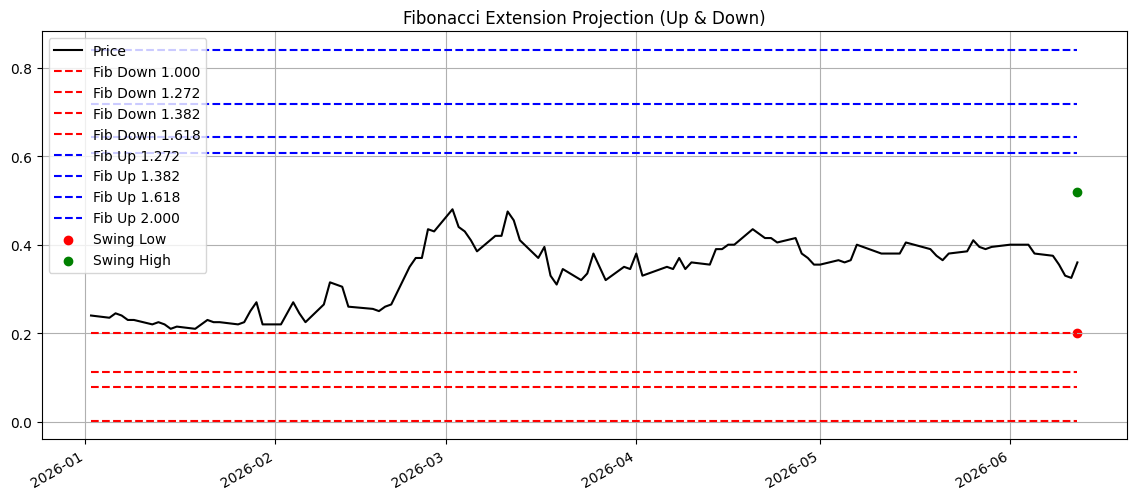

In [19]:
fib_result = fibonacci_extension.compute_fibonacci_extension(df.copy().reset_index())
fib_result

In [20]:
output_dir = Path("/workspace/data/figures/")
output_dir.mkdir(parents=True, exist_ok=True)
output_path = output_dir / f"{code}_fibonacci_extension_{dt.datetime.now().strftime('%Y-%m-%d')}.png"
fib_result["plot_obj"].savefig(output_path, dpi=300, bbox_inches="tight")

In [21]:
lg_financials_data = request_api.get_corp_financials_data(code=code, market=market)
lg_balance_sheet_data = request_api.get_corp_balance_sheet_data(code=code, market=market)
lg_cash_flow_data = request_api.get_corp_cash_flow_data(code=code, market=market)
lg_earnings_data = request_api.get_corp_earnings_data(code=code, market=market)
lg_quarterly_earnings_data = request_api.get_corp_quarterly_earnings_data(code=code, market=market)

GET response: {'detail': 'Corporate finance data not found'}
GET response: {'detail': 'Balance sheet data not found'}
GET response: {'detail': 'Cash flow data not found'}
GET response: {'detail': 'Earnings data not found'}
GET response: {'detail': 'Quarterly earnings data not found'}


In [ ]:
md_file_path =pdf_to_md.pdf_url_to_markdown(
    pdf_url="https://lahontangoldcorp.com/wp-content/uploads/2026/05/Lahontan-MDA-March-31-2026-vFinal-Compress.pdf",
    directory_path="/workspace/data",
)
md_file_path

MissingSchema: Invalid URL '': No scheme supplied. Perhaps you meant https://?

In [ ]:
md_file_path =pdf_to_md.pdf_url_to_markdown(
    pdf_url="",
    directory_path="/workspace/data",
)
md_file_path

In [ ]:
md_file_path =pdf_to_md.pdf_url_to_markdown(
    pdf_url="",
    directory_path="/workspace/data",
)
md_file_path

In [ ]:
md_file_path =pdf_to_md.pdf_url_to_markdown(
    pdf_url='',
    directory_path="/workspace/data",
)
md_file_path

In [ ]:
md_file_path = webpage_to_markdown.webpage_to_markdown(
    url='https://www.equinoxgold.com/news/equinox-and-orla-mining-combine-to-create-north-americas-new-senior-gold-producer-built-to-grow-built-to-last/',
    directory_path="/workspace/data",
)
md_file_path